# Rozwiązywanie równań nieliniowych metodą Newtona-Raphsona oraz metodą siecznych

## Dane:
Moja funkcja to:   
$$
    f(x) = mxe^{-n} - me^{-nx} + \frac{1}{m}, x \in [a, b] \\[2ex] n = 10, m = 17, a = -0.4, b = 1.0
$$
Co daje:
$$
    f(x) = 17xe^{-10} - 17e^{-10x}+\frac{1}{17} \\[2ex]
    f'(x) = 170e^{-10x} + 17e^{-10}
$$


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

M, N = 17, 10
A, B = -0.4, 1.0
rho_values = [1e-2, 1e-3, 1e-4, 1e-5, 1e-7, 1e-10, 1e-15]

# Rozwiązanie wyliczone kalkulatorem Wolfram Alpha
SOLUTION = 0.5659029143251876753013761073043433277

def f(x):
    return M * x * np.exp(-N) - M * np.exp(-N * x) + 1/M

def df(x):
    return M * np.exp(-N) + M * N * np.exp(-N * x)

## Metoda Newtona-Raphsona
Dla tej metody musimy wybrać jeden punkt początkowy, a następnie będziemy na jego podstawie stosować wzór iteracyjny z wykładu. Jako punkty początkowe wybieramy kolejno:

$$
    x_0 = 1.0, 0.9, 0.8, \dots, -0.3, -0.4
$$

Wzór iteracyjny:

$$
    x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}
$$

Zatrzymujemy iterowanie gdy osiągniemy kryterium stopu, których wyróżniamy trzy w ramach naszego rozwiązania. Poniżej znajdują się pierwsze dwa, nazywane kolejno przyrostowym oraz residualnym:

1.  Przyrostowe: $|x_{i+1} - x_i| < \rho$
2.  Residualne: $|f(x_i)| < \rho$

W ramach dodatkowego zabezpieczenia przed rozbieżnym cyklem musimy również wprowadzić kryterium maksymalnej iteracji, czyli liczby iteracji, której nie możemy przekroczyć.

W celu zbadania zbieżności zapisujemy wszystkie pośrednie $x_i$.

### Na co należy uważać?
Możliwe problemy przy płaskich miejscach, czyli takich, gdzie $f'(x) \approx 0$,
ponieważ wtedy wyskakujemy poza przedział z naszym $x_{i+1}$. Drugim problemem wynikającym z płaskości jest płaskość przy samej osi OX. Możemy przedwcześnie skończyć poszukiwanie miejsca zerowego, gdyż spełnimy kryterium $|f(x_i)| < \rho$.

**Uwaga:** funkcja $f$ nie spełnia jednego z warunków "twierdzenia o wyborze przedziału dla N-R" z wykładu:

$$
\left| \frac{f(1)}{f'(1)} \right| \approx 7 \not < (1 - (-0.4)) = 1.4
$$

Konsekwencją tego jest brak gwarantowanej zbieżności metody Newtona-Raphsona.

In [34]:
def newton_raphson(x0, rho, stop_criterion, max_iter=100):
    history = [x0]
    x_curr = x0
    
    for _ in range(max_iter):
        fx = f(x_curr)
        dfx = df(x_curr)
        
        # Zabezpieczenie przed dzieleniem przez zero 
        if abs(dfx) < 1e-15:
            return None, history, "Błąd: f'(x) bliskie 0"
            
        # Główny wzór iteracyjny
        x_next = x_curr - fx / dfx
        history.append(x_next)
        
        # Sprawdzanie kryterium stopu
        converged = False
        if stop_criterion == "incremental":
            if abs(x_next - x_curr) < rho:
                converged = True
        elif stop_criterion == "residual":
            if abs(f(x_next)) < rho:
                converged = True
                
        if converged:
            return x_next, history, "Sukces"
        
        x_curr = x_next
        
    return x_curr, history, "Osiągnięto limit iteracji"

In [35]:
# Konfiguracja eksperymentu
x0_values = np.round(np.arange(1.0, -0.5, -0.1), 1)
criteria = ["incremental", "residual"]

all_results = []

for rho in rho_values:
    for x0 in x0_values:
        for crit in criteria:
            root, hist, status = newton_raphson(x0, rho, crit)
            
            final_error = abs(root - SOLUTION) if root is not None else None
            
            all_results.append({
                "Metoda": "Newton-Raphson",
                "x0": x0,
                "Rho": rho,
                "Kryterium": crit,
                "Wyznaczony_Pierwiastek": root,
                "Liczba_Iteracji": len(hist) - 1,
                "Blad_Bezwzgledny": final_error,
                "Status": status
            })

df_newton = pd.DataFrame(all_results)
df_newton.to_csv("wyniki_newton_raphson.csv", index=False, sep=';', encoding='utf-8-sig')

print("Eksperyment zakończony. Dane zapisano do 'wyniki_newton_raphson.csv'.")
df_newton.head()

Eksperyment zakończony. Dane zapisano do 'wyniki_newton_raphson.csv'.


,Metoda,x0,Rho,Kryterium,Wyznaczony_Pierwiastek,Liczba_Iteracji,Blad_Bezwzgledny,Status
0,Newton-Raphson,1.0,0.01,incremental,0.565458,68,0.000445,Sukces
1,Newton-Raphson,1.0,0.01,residual,0.556315,67,0.009588,Sukces
2,Newton-Raphson,0.9,0.01,incremental,0.565900,27,0.000002,Sukces
3,Newton-Raphson,0.9,0.01,residual,0.553831,25,0.012072,Sukces
4,Newton-Raphson,0.8,0.01,incremental,0.565440,10,0.000462,Sukces


## Metoda Siecznych
W tej metodzie nie musimy znać pochodnej funkcji $f'(x)$. Zamiast niej stosujemy iloraz różnicowy obliczany z dwóch poprzednich punktów.

### Punkty startowe
Dla każdego eksperymentu musimy wybrać dwa punkty startowe $x_0$ oraz $x_1$:
* Pierwszy punkt ($x_0$): dobieramy tak samo jak w metodzie Newtona ($1.0, \dots, -0.4$).
* Drugi punkt ($x_1$): wybieramy jako jeden z końców przedziału, czyli raz $x_1 = a = -0.4$, a w drugim wariancie $x_1 = b = 1.0$.

### Wzór iteracyjny
$$
    x_{i+2} = x_{i+1} - \frac{x_{i+1} - x_i}{f(x_{i+1}) - f(x_i)} \cdot f(x_{i+1})
$$

### Kryteria stopu
Stosujemy te same trzy kryteria co w metodzie Newtona, aby umożliwić rzetelne porównanie wyników:
1.  Przyrostowe: $|x_{i+1} - x_i| < \rho$
2.  Residualne: $|f(x_i)| < \rho$
3.  Maksymalna liczba iteracji: limit kroków zabezpieczający przed nieskończoną pętlą w przypadku braku zbieżności.

### Charakterystyka metody
* Rząd zbieżności: wynosi ok. **1.62**. Jest to zbieżność szybsza niż liniowa, ale wolniejsza niż kwadratowa (Newtona).
* Zaleta: brak konieczności wyliczania pochodnej analitycznej funkcji.

### Na co należy uważać?
* Dzielenie przez zero: jeśli $f(x_{i+1}) = f(x_i)$, mianownik we wzorze wyzeruje się, co uniemożliwi dalsze obliczenia.
* Brak stabilności przedziału: metoda nie gwarantuje, że pierwiastek będzie znajdował się zawsze pomiędzy punktami $x_i$ a $x_{i+1}$, co może wyprowadzić iteracje poza badany zakres.
* Wpływ punktu startowego: wybór punktu $x_0$ istotnie wpływa na tempo zbieżności w początkowej fazie algorytmu.

In [36]:
def secant_method(x0, x1, rho, stop_criterion, max_iter=100):
    f0 = f(x0)
    f1 = f(x1)
    history = [x0, x1]
    
    for _ in range(max_iter):
        # Unikanie dzielenia przez zero 
        if abs(f1 - f0) < 1e-15:
            return None, history, "Blad: f(x1) - f(x0) bliskie 0"
        
        # Wzór iteracyjny metody siecznych 
        x_next = x1 - (x1 - x0) * f1 / (f1 - f0)
        history.append(x_next)
        f_next = f(x_next)
        
        # Sprawdzanie kryteriów stopu
        converged = False
        if stop_criterion == "incremental":
            if abs(x_next - x1) < rho:
                converged = True
        elif stop_criterion == "residual":
            if abs(f_next) < rho:
                converged = True
        
        if converged:
            return x_next, history, "Sukces"
        
        # Przesunięcie punktów do kolejnego kroku
        x0, x1 = x1, x_next
        f0, f1 = f1, f_next
        
    return x1, history, "Osiagnieto limit iteracji"

In [37]:
# Konfiguracja eksperymentu
x0_values = np.round(np.arange(1.0, -0.5, -0.1), 1)
x1_options = [A, B]
criteria = ["incremental", "residual"]

secant_results = []

for rho in rho_values:
    for x0 in x0_values:
        for x1 in x1_options:
            # Unikamy przypadku x0 == x1, który zabiłby metodę na starcie
            if abs(x0 - x1) < 1e-9:
                continue
                
            for crit in criteria:
                root, hist, status = secant_method(x0, x1, rho, crit)
                
                final_error = abs(root - SOLUTION) if root is not None else None
                
                secant_results.append({
                    "Metoda": "Sieczne",
                    "x0": x0,
                    "x1": x1,
                    "Rho": rho,
                    "Kryterium": crit,
                    "Wyznaczony_Pierwiastek": root,
                    "Liczba_Iteracji": len(hist) - 2, # -2 bo mamy dwa punkty startowe
                    "Blad_Bezwzgledny": final_error,
                    "Status": status
                })

# Zapis do CSV
df_secant = pd.DataFrame(secant_results)
df_secant.to_csv("wyniki_sieczne.csv", index=False, sep=';', encoding='utf-8-sig')

print("Eksperyment dla metody siecznych zakończony. Dane zapisano do 'wyniki_sieczne.csv'.")
df_secant.head()

Eksperyment dla metody siecznych zakończony. Dane zapisano do 'wyniki_sieczne.csv'.


,Metoda,x0,x1,Rho,Kryterium,Wyznaczony_Pierwiastek,Liczba_Iteracji,Blad_Bezwzgledny,Status
0,Sieczne,1.0,-0.4,0.01,incremental,0.999823,2,0.433920,Sukces
1,Sieczne,1.0,-0.4,0.01,residual,NaN,5,NaN,Blad: f(x1) - f(x0) bliskie 0
2,Sieczne,0.9,-0.4,0.01,incremental,0.899839,2,0.333936,Sukces
3,Sieczne,0.9,-0.4,0.01,residual,0.899839,100,0.333936,Osiagnieto limit iteracji
4,Sieczne,0.9,1.0,0.01,incremental,1.000000,3,0.434097,Sukces


## Część wizualizacyjna

### Krok 1: Wykres funkcji

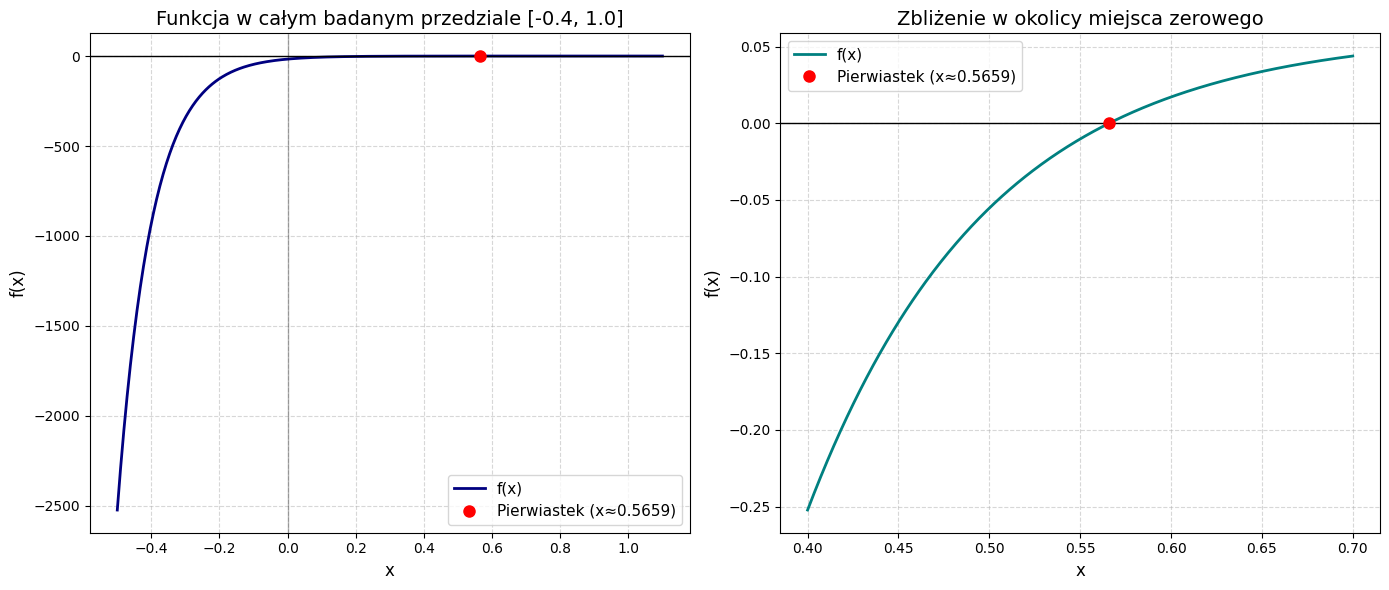

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parametry Twojej funkcji
M, N = 17, 10
SOLUTION = 0.5659029143251876753

def f(x):
    return M * x * np.exp(-N) - M * np.exp(-N * x) + 1/M

# 2. Generowanie siatki punktów (dziedziny)
# Wykres 1: Pełen badany przedział (z lekkim marginesem dla lepszej widoczności)
x_full = np.linspace(-0.5, 1.1, 500)
y_full = f(x_full)

# Wykres 2: Zbliżenie na miejsce zerowe (np. od 0.4 do 0.7)
x_zoom = np.linspace(0.4, 0.7, 500)
y_zoom = f(x_zoom)

# 3. Tworzenie figury z dwoma wykresami (1 wiersz, 2 kolumny)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Wykres 1: Pełny widok ---
ax1.plot(x_full, y_full, label='f(x)', color='navy', linewidth=2)
ax1.axhline(0, color='black', linewidth=1) # Oś X
ax1.axvline(0, color='black', linewidth=1, alpha=0.3) # Oś Y
# Zaznaczenie miejsca zerowego
ax1.plot(SOLUTION, 0, 'ro', markersize=8, label=f'Pierwiastek (x≈{SOLUTION:.4f})')

ax1.set_title('Funkcja w całym badanym przedziale [-0.4, 1.0]', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('f(x)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=11)

# --- Wykres 2: Zbliżenie (Zoom) ---
ax2.plot(x_zoom, y_zoom, label='f(x)', color='teal', linewidth=2)
ax2.axhline(0, color='black', linewidth=1) # Oś X
# Zaznaczenie miejsca zerowego
ax2.plot(SOLUTION, 0, 'ro', markersize=8, label=f'Pierwiastek (x≈{SOLUTION:.4f})')

ax2.set_title('Zbliżenie w okolicy miejsca zerowego', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('f(x)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=11)

# 4. Zapis do pliku i wyświetlenie
plt.tight_layout() # Automatycznie dopasowuje odstępy, żeby teksty się nie nachodziły
plt.savefig('wykresy_funkcji_f.png', dpi=300, bbox_inches='tight')
plt.show()

### Krok 2: tabela $x_p$

In [39]:
import pandas as pd

# Odczyt danych wygenerowanych z poprzednich kroków
df_newton = pd.read_csv('wyniki_newton_raphson.csv', sep=';')

# Funkcja pomocnicza do tworzenia przekształconej tabeli
def stworz_tabele(df, kryterium, wartosc):
    # Wyciągamy dane tylko dla konkretnego kryterium
    dane_filtrowane = df[df['Kryterium'] == kryterium]
    
    # Tworzymy tabelę przestawną
    tabela = dane_filtrowane.pivot(index='x0', columns='Rho', values=wartosc)
    
    # Sortujemy index x0 malejąco (żeby było jak w sprawozdaniu: od 1.0 do -0.4)
    tabela = tabela.sort_index(ascending=False)
    
    # Mapujemy nazwy kolumn ładnie dla odczytu
    tabela.columns = [f"rho = {col}" for col in tabela.columns]
    
    return tabela

# Generujemy Tabele 1 i 2 (Wyznaczone pierwiastki)
tabela1 = stworz_tabele(df_newton, 'incremental', 'Wyznaczony_Pierwiastek')
tabela2 = stworz_tabele(df_newton, 'residual', 'Wyznaczony_Pierwiastek')

# Wyświetlanie tabel z odpowiednim formatowaniem liczb (6 miejsc po przecinku)
print("Kryterium Przyrostowe:")
display(tabela1.style.format("{:.6f}"))

print("\\nKryterium Rezydualne:")
display(tabela2.style.format("{:.6f}"))

Kryterium Przyrostowe:


,rho = 1e-15,rho = 1e-10,rho = 1e-07,rho = 1e-05,rho = 0.0001,rho = 0.001,rho = 0.01
x0,,,,,,,
1.000000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565902,0.565458
0.900000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565900,0.565900
0.800000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565902,0.565440
0.700000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565903,0.565886
0.600000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565903,0.565695
0.500000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565903,0.565892
0.400000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565903,0.565843
0.300000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565903,0.565810
0.200000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565903,0.565796


\nKryterium Rezydualne:


,rho = 1e-15,rho = 1e-10,rho = 1e-07,rho = 1e-05,rho = 0.0001,rho = 0.001,rho = 0.01
x0,,,,,,,
1.000000,0.565903,0.565903,0.565903,0.565902,0.565902,0.565458,0.556315
0.900000,0.565903,0.565903,0.565903,0.565900,0.565900,0.565204,0.553831
0.800000,0.565903,0.565903,0.565903,0.565902,0.565902,0.565440,0.556123
0.700000,0.565903,0.565903,0.565903,0.565886,0.565886,0.565886,0.564067
0.600000,0.565903,0.565903,0.565903,0.565903,0.565903,0.565695,0.559381
0.500000,0.565903,0.565903,0.565903,0.565892,0.565892,0.564438,0.564438
0.400000,0.565903,0.565903,0.565903,0.565903,0.565843,0.565843,0.562406
0.300000,0.565903,0.565903,0.565903,0.565903,0.565810,0.565810,0.561561
0.200000,0.565903,0.565903,0.565903,0.565903,0.565796,0.565796,0.561241


### Krok 3: heatmapy

Generowanie map ciepła dla metody Newtona-Raphsona...


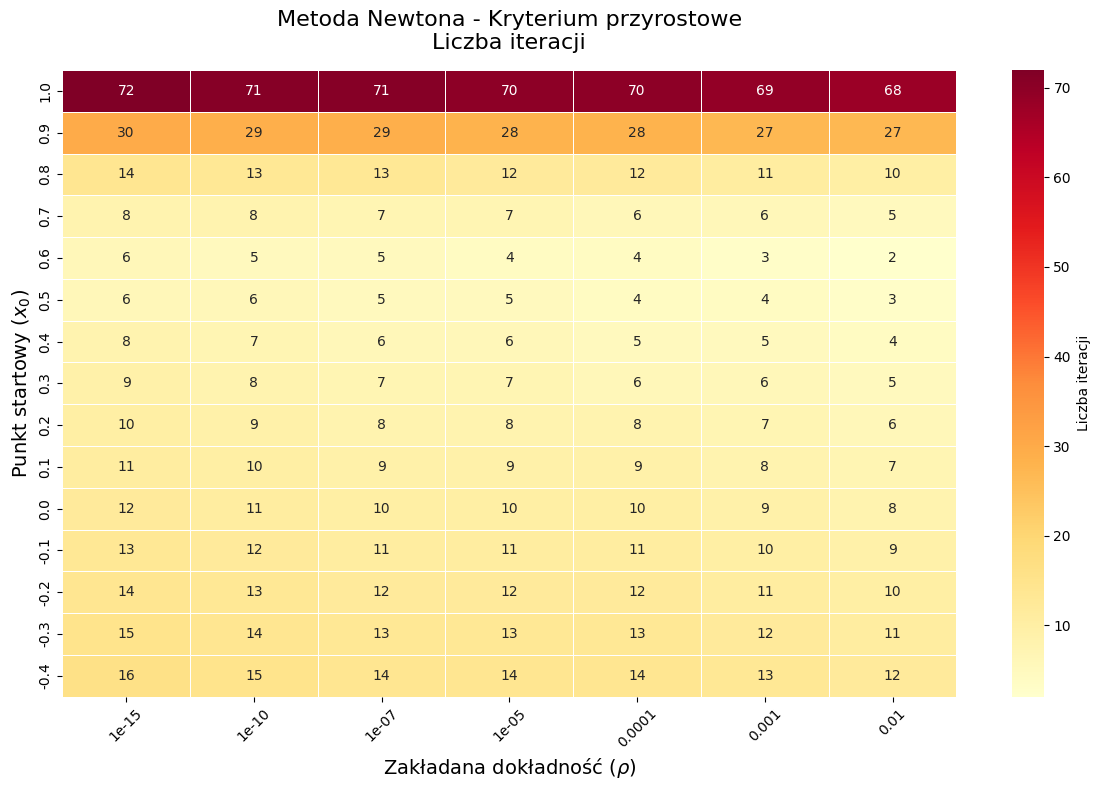

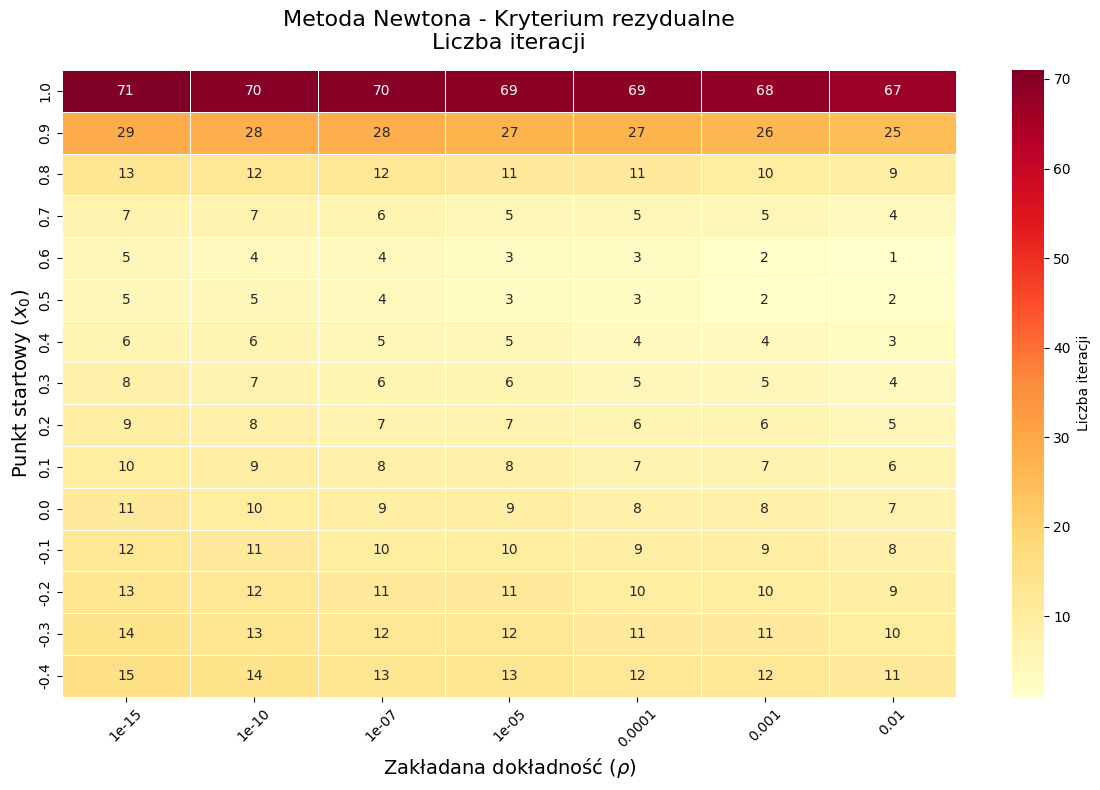

Generowanie map ciepła dla metody Siecznych (x1 = -0.4)...


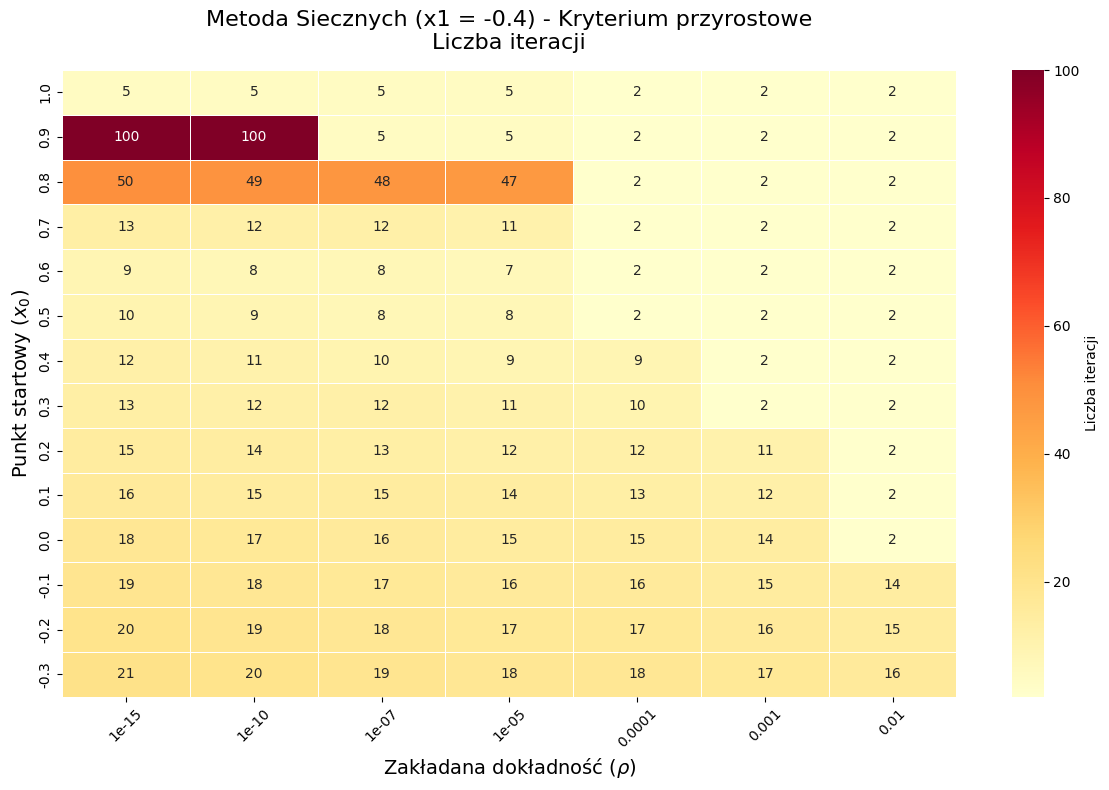

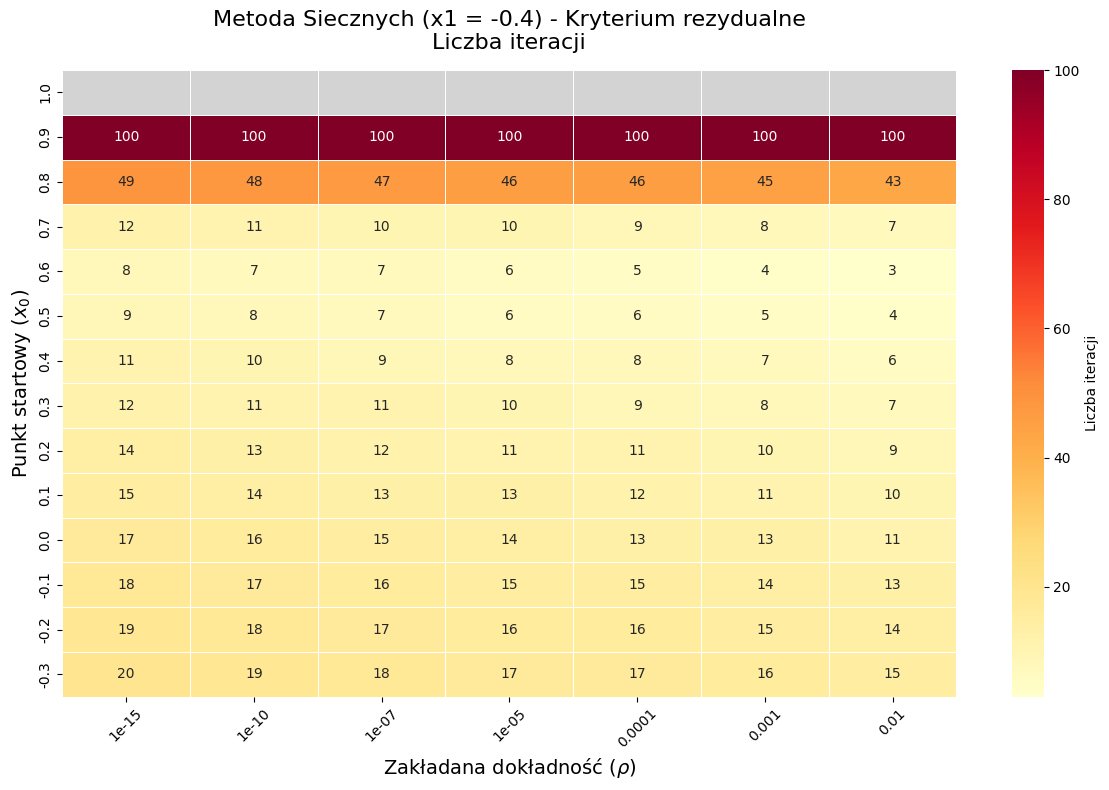

Generowanie map ciepła dla metody Siecznych (x1 = 1.0)...


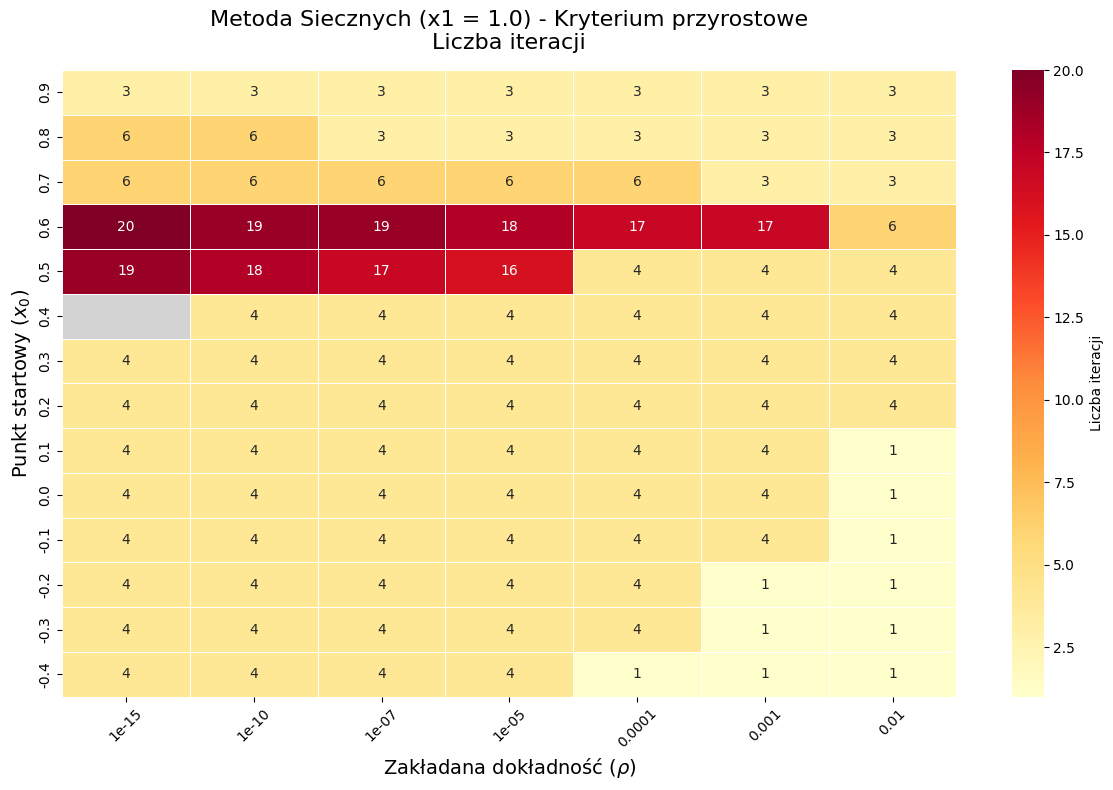

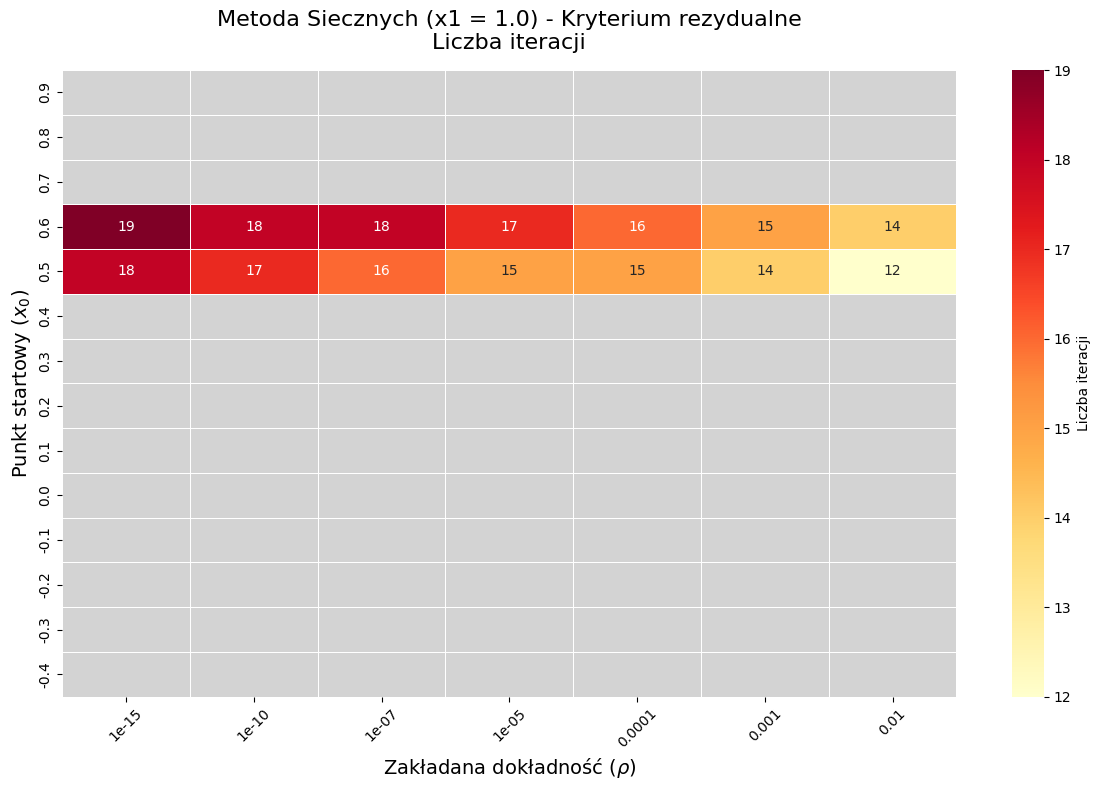

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Wczytanie danych z wygenerowanych wcześniej plików CSV
df_newton = pd.read_csv('wyniki_newton_raphson.csv', sep=';')
df_sieczne = pd.read_csv('wyniki_sieczne.csv', sep=';')

# 2. Definicja uniwersalnej funkcji do rysowania heatmapy
def rysuj_heatmapy_iteracji(df, nazwa_metody, kryterium, x1=None):
    
    # Dostosowanie polskiej nazwy dla kryterium
    kryterium_pl = "przyrostowe" if kryterium == "incremental" else "rezydualne"
    
    # Filtrowanie danych względem kryterium oraz opcjonalnie punktu x1 (dla siecznych)
    if x1 is not None:
        df_filtered = df[(df['Kryterium'] == kryterium) & (df['x1'] == x1)]
        tytul = f"{nazwa_metody} (x1 = {x1}) - Kryterium {kryterium_pl}\nLiczba iteracji"
        nazwa_pliku = f"heatmap_{nazwa_metody.replace(' ', '_')}_{kryterium}_x1_{str(x1).replace('.', '_')}.png"
    else:
        df_filtered = df[df['Kryterium'] == kryterium]
        tytul = f"{nazwa_metody} - Kryterium {kryterium_pl}\nLiczba iteracji"
        nazwa_pliku = f"heatmap_{nazwa_metody.replace(' ', '_')}_{kryterium}.png"
        
    # Przekształcenie płaskiej tabeli w macierz (wiersze: x0, kolumny: Rho, wartości: Liczba_Iteracji)
    pivot_iter = df_filtered.pivot(index='x0', columns='Rho', values='Liczba_Iteracji')
    
    # Sortowanie osi Y od największego do najmniejszego x0
    pivot_iter = pivot_iter.sort_index(ascending=False)
    
    # Inicjalizacja wykresu
    plt.figure(figsize=(12, 8))
    
    # Tworzymy maskę, aby ukryć wartości NaN (tam, gdzie algorytm zawiódł)
    pivot_root = df_filtered.pivot(index='x0', columns='Rho', values='Wyznaczony_Pierwiastek')
    pivot_root = pivot_root.sort_index(ascending=False)
    maska_nan = pivot_root.isna()
    
    # Ustawienie szarego tła osi, które będzie widoczne w miejscach z wartościami NaN
    ax = plt.axes()
    ax.set_facecolor("lightgrey")
    
    # Rysowanie mapy ciepła za pomocą Seaborn
    # cmap="YlOrRd" (Yellow-Orange-Red) - mało iteracji = jasno, dużo iteracji = ciemnoczerwono
    sns.heatmap(pivot_iter, annot=True, fmt=".0f", cmap="YlOrRd", 
                mask=maska_nan, cbar_kws={'label': 'Liczba iteracji'},
                linewidths=0.5, linecolor='white', ax=ax)
    
    # Estetyka wykresu
    plt.title(tytul, fontsize=16, pad=15)
    plt.xlabel(r'Zakładana dokładność ($\rho$)', fontsize=14)
    plt.ylabel(r'Punkt startowy ($x_0$)', fontsize=14)
    plt.xticks(rotation=45) # Lekkie obrócenie etykiet na osi X dla lepszej czytelności
    
    # Zapis i wyświetlenie
    plt.tight_layout()
    plt.savefig(nazwa_pliku, dpi=300, bbox_inches='tight')
    plt.show()

# 3. Wywołanie funkcji dla poszczególnych przypadków
print("Generowanie map ciepła dla metody Newtona-Raphsona...")
rysuj_heatmapy_iteracji(df_newton, "Metoda Newtona", "incremental")
rysuj_heatmapy_iteracji(df_newton, "Metoda Newtona", "residual")

print("Generowanie map ciepła dla metody Siecznych (x1 = -0.4)...")
rysuj_heatmapy_iteracji(df_sieczne, "Metoda Siecznych", "incremental", x1=-0.4)
rysuj_heatmapy_iteracji(df_sieczne, "Metoda Siecznych", "residual", x1=-0.4)

print("Generowanie map ciepła dla metody Siecznych (x1 = 1.0)...")
rysuj_heatmapy_iteracji(df_sieczne, "Metoda Siecznych", "incremental", x1=1.0)
rysuj_heatmapy_iteracji(df_sieczne, "Metoda Siecznych", "residual", x1=1.0)